# ML Models - Olist E-Commerce (Spark MLlib)

In [6]:
import os, sys, json, logging
from datetime import datetime
os.environ['TZ'] = 'Asia/Ho_Chi_Minh'
PYTHON_PATH = "C:/Users/Admin/AppData/Local/Programs/Python/Python312/python.exe"
os.environ["PYSPARK_PYTHON"] = PYTHON_PATH
os.environ["PYSPARK_DRIVER_PYTHON"] = PYTHON_PATH

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StandardScaler, StringIndexer
from pyspark.ml.clustering import KMeans
from pyspark.ml.classification import RandomForestClassifier, LogisticRegression, GBTClassifier
from pyspark.ml.regression import RandomForestRegressor, LinearRegression as SparkLinearRegression
from pyspark.ml.evaluation import (
    ClusteringEvaluator, BinaryClassificationEvaluator,
    MulticlassClassificationEvaluator, RegressionEvaluator
)
from pyspark.ml.functions import vector_to_array

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
logger = logging.getLogger("OlistML")


Khởi tạo SparkSession (local[2], tối ưu cho máy yếu)

In [7]:
spark = (
    SparkSession.builder
    .appName("Olist_ML_Models")
    .config("spark.sql.session.timeZone", "Asia/Ho_Chi_Minh")
    .master("local[2]")
    .config("spark.driver.memory", "2g")
    .config("spark.sql.shuffle.partitions", "4")
    .config("spark.ui.enabled", "false")
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.driver.host", "127.0.0.1")
    .config("spark.driver.bindAddress", "127.0.0.1")
    .config("spark.pyspark.python", PYTHON_PATH)
    .config("spark.pyspark.driver.python", PYTHON_PATH)
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")
print("SparkSession OK -", spark.version)


SparkSession OK - 3.5.1


In [8]:
HDFS_SILVER = "hdfs://localhost:9000/user/bigdata/olist/silver"
HDFS_GOLD   = "hdfs://localhost:9000/user/bigdata/olist/gold"
HDFS_MODELS = "hdfs://localhost:9000/user/bigdata/olist/models"


## 1. Đọc dữ liệu đã xử lý từ HDFS (output của ETL)

In [9]:
merged_df = spark.read.parquet(f"{HDFS_SILVER}/merged_orders")
rfm_df = spark.read.parquet(f"{HDFS_GOLD}/rfm_customers")

merged_count = merged_df.count()
rfm_count = rfm_df.count()
print(f"merged_orders: {merged_count:,} dòng, {len(merged_df.columns)} cột")
print(f"rfm_customers: {rfm_count:,} dòng, {len(rfm_df.columns)} cột")

merged_df.cache()
rfm_df.cache()


merged_orders: 99,277 dòng, 59 cột
rfm_customers: 93,358 dòng, 16 cột


DataFrame[customer_unique_id: string, recency: int, frequency: bigint, monetary: double, avg_review_score: double, avg_delivery_days: double, avg_items_per_order: double, customer_state: string, customer_city: string, last_purchase_date: timestamp, first_purchase_date: timestamp, customer_tenure_days: int, r_score: int, f_score: int, m_score: int, rfm_score: int]

Kiểm tra schema và mẫu dữ liệu RFM

In [10]:
rfm_df.printSchema()
rfm_df.limit(10).toPandas()


root
 |-- customer_unique_id: string (nullable = true)
 |-- recency: integer (nullable = true)
 |-- frequency: long (nullable = true)
 |-- monetary: double (nullable = true)
 |-- avg_review_score: double (nullable = true)
 |-- avg_delivery_days: double (nullable = true)
 |-- avg_items_per_order: double (nullable = true)
 |-- customer_state: string (nullable = true)
 |-- customer_city: string (nullable = true)
 |-- last_purchase_date: timestamp (nullable = true)
 |-- first_purchase_date: timestamp (nullable = true)
 |-- customer_tenure_days: integer (nullable = true)
 |-- r_score: integer (nullable = true)
 |-- f_score: integer (nullable = true)
 |-- m_score: integer (nullable = true)
 |-- rfm_score: integer (nullable = true)



,customer_unique_id,recency,frequency,monetary,avg_review_score,avg_delivery_days,avg_items_per_order,customer_state,customer_city,last_purchase_date,first_purchase_date,customer_tenure_days,r_score,f_score,m_score,rfm_score
0,0a0a92112bd4c708ca5fde585afaa872,334,1,13664.08,1.0,18.0,8.0,RJ,rio de janeiro,2017-09-29 22:24:52,2017-09-29 22:24:52,0,3,3,1,7
1,da122df9eeddfedc1dc1f5349a1a690c,515,2,7571.63,5.0,16.0,1.0,RJ,araruama,2017-04-01 22:58:41,2017-04-01 22:58:40,0,4,1,1,6
2,763c8b1c9c68a0229c42c9fc6f662b93,45,1,7274.88,1.0,11.0,4.0,ES,vila velha,2018-07-15 21:49:44,2018-07-15 21:49:44,0,1,1,1,3
3,dc4802a71eae9be1dd28f5d788ceb526,563,1,6929.31,5.0,19.0,1.0,MS,campo grande,2017-02-13 03:37:36,2017-02-13 03:37:36,0,4,4,1,9
4,459bef486812aa25204be022145caa62,35,1,6922.21,0.0,21.0,1.0,ES,vitoria,2018-07-26 01:10:17,2018-07-26 01:10:17,0,1,1,1,3
5,ff4159b92c40ebe40454e3e6a7c35ed6,462,1,6726.66,5.0,12.0,1.0,SP,marilia,2017-05-25 01:14:34,2017-05-25 01:14:34,0,4,4,1,9
6,4007669dec559734d6f53e029e360987,278,1,6081.54,1.0,19.0,6.0,MG,divinopolis,2017-11-24 18:03:35,2017-11-24 18:03:35,0,3,3,1,7
7,eebb5dda148d3893cdaf5b5ca3040ccb,498,1,4764.34,4.0,19.0,1.0,SP,maua,2017-04-19 01:50:13,2017-04-19 01:50:13,0,4,4,1,9
8,48e1ac109decbb87765a3eade6854098,68,1,4681.78,5.0,14.0,1.0,PB,joao pessoa,2018-06-22 19:23:19,2018-06-22 19:23:19,0,1,1,1,3
9,c8460e4251689ba205045f3ea17884a1,21,4,4655.91,4.0,12.0,6.0,RS,porto alegre,2018-08-08 21:27:15,2018-08-07 16:03:02,1,1,1,1,3


Trực quan phân bố RFM đầu vào

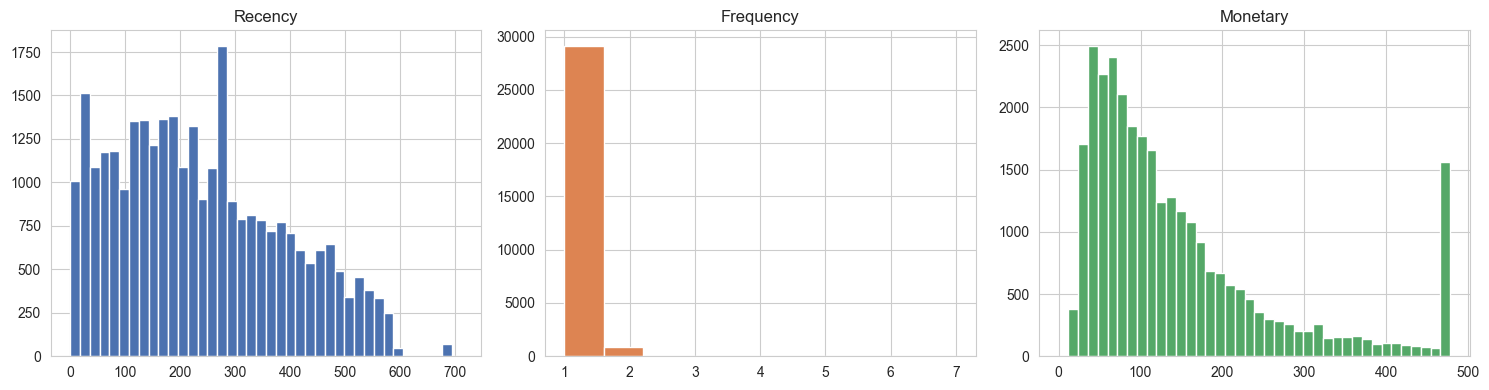

In [11]:
rfm_sample = rfm_df.select("recency", "frequency", "monetary").sample(
    fraction=min(1.0, 30000 / rfm_count), seed=42
).toPandas()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(rfm_sample["recency"], bins=40, color="#4C72B0")
axes[0].set_title("Recency")
axes[1].hist(rfm_sample["frequency"].clip(upper=10), bins=10, color="#DD8452")
axes[1].set_title("Frequency")
axes[2].hist(rfm_sample["monetary"].clip(upper=rfm_sample["monetary"].quantile(0.95)), bins=40, color="#55A868")
axes[2].set_title("Monetary")
plt.tight_layout()
plt.show()


## 2. Mô hình 1 - K-Means Customer Segmentation

Chuẩn bị dữ liệu (loại null) cho phân cụm

In [12]:
kmeans_feature_cols = ["recency", "frequency", "monetary"]
clean_df = (
    rfm_df
    .select("customer_unique_id", *kmeans_feature_cols)
    .na.drop(subset=kmeans_feature_cols)
)
data_count = clean_df.count()
print(f"Dữ liệu K-Means: {data_count:,} khách hàng")


Dữ liệu K-Means: 93,358 khách hàng


Pipeline: VectorAssembler → StandardScaler → KMeans(k=4)

In [13]:
assembler = VectorAssembler(inputCols=kmeans_feature_cols, outputCol="features_raw")
scaler = StandardScaler(inputCol="features_raw", outputCol="features", withStd=True, withMean=True)
kmeans = KMeans(featuresCol="features", predictionCol="cluster", k=4, seed=42, maxIter=30)
pipeline = Pipeline(stages=[assembler, scaler, kmeans])

print("Đang huấn luyện K-Means (k=4)...")
kmeans_pipeline_model = pipeline.fit(clean_df)
predictions = kmeans_pipeline_model.transform(clean_df)
print("Huấn luyện xong.")


Đang huấn luyện K-Means (k=4)...
Huấn luyện xong.


Đánh giá Silhouette Score

In [14]:
evaluator = ClusteringEvaluator(featuresCol="features", predictionCol="cluster", metricName="silhouette")
silhouette = evaluator.evaluate(predictions)
print(f"Silhouette Score: {silhouette:.4f}")


Silhouette Score: 0.3054


Đặt tên segment dựa vào cluster centers (Champions / Loyal / At Risk / Lost)

In [15]:
kmeans_model = kmeans_pipeline_model.stages[-1]
centers = kmeans_model.clusterCenters()

indexed_centers = [(i, float(centers[i][2])) for i in range(len(centers))]
indexed_centers.sort(key=lambda x: x[1], reverse=True)

segment_names = ["Champions", "Loyal", "At Risk", "Lost"]
cluster_to_segment = {}
for rank, (cluster_id, monetary_val) in enumerate(indexed_centers):
    cluster_to_segment[cluster_id] = segment_names[rank]
    print(f"Cluster {cluster_id} -> {segment_names[rank]}")

condition = None
for cid, name in cluster_to_segment.items():
    condition = (F.when(F.col("cluster") == cid, F.lit(name)) if condition is None
                 else condition.when(F.col("cluster") == cid, F.lit(name)))
condition = condition.otherwise(F.lit("Unknown"))

segmented_df = predictions.withColumn("segment_name", condition)


Cluster 2 -> Champions
Cluster 1 -> Loyal
Cluster 3 -> At Risk
Cluster 0 -> Lost


Thống kê phân bố phân khúc khách hàng

In [16]:
segment_stats = {}
for cid, name in cluster_to_segment.items():
    count = segmented_df.filter(F.col("cluster") == cid).count()
    segment_stats[name] = int(count)
    print(f"{name}: {count:,} khách hàng")

segment_stats_df = pd.DataFrame(list(segment_stats.items()), columns=["segment", "count"])
segment_stats_df


Champions: 2,807 khách hàng
Loyal: 33,796 khách hàng
At Risk: 22,276 khách hàng
Lost: 34,479 khách hàng


,segment,count
0,Champions,2807
1,Loyal,33796
2,At Risk,22276
3,Lost,34479


Trực quan phân khúc khách hàng

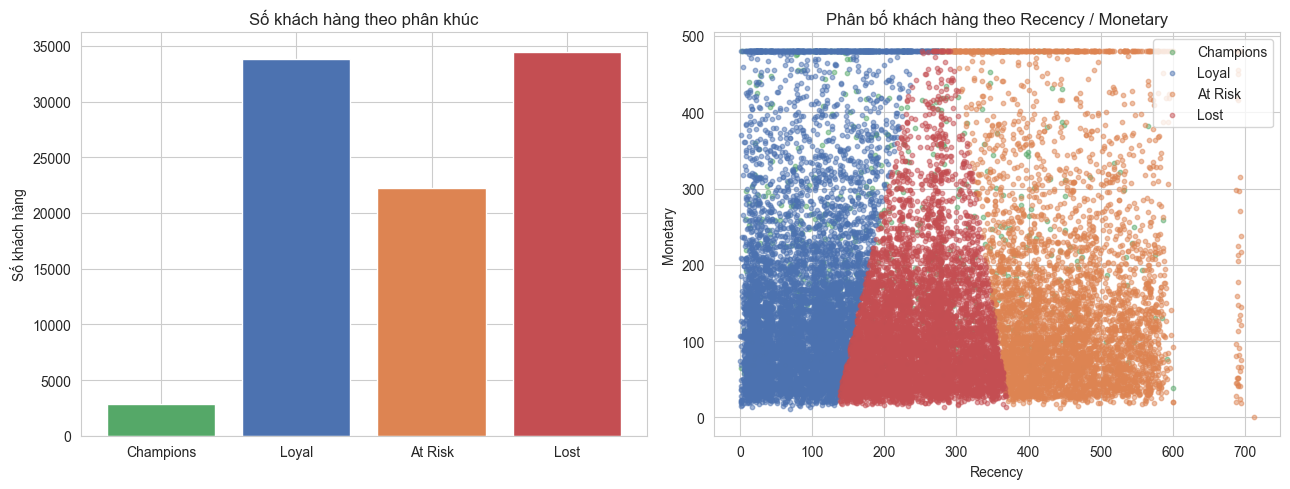

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors_map = {"Champions": "#55A868", "Loyal": "#4C72B0", "At Risk": "#DD8452", "Lost": "#C44E52"}
bar_colors = [colors_map.get(s, "#8172B2") for s in segment_stats_df["segment"]]
axes[0].bar(segment_stats_df["segment"], segment_stats_df["count"], color=bar_colors)
axes[0].set_title("Số khách hàng theo phân khúc")
axes[0].set_ylabel("Số khách hàng")

seg_sample = segmented_df.select("recency", "frequency", "monetary", "segment_name").sample(
    fraction=min(1.0, 20000 / data_count), seed=42
).toPandas()
for seg, color in colors_map.items():
    sub = seg_sample[seg_sample["segment_name"] == seg]
    axes[1].scatter(sub["recency"], sub["monetary"].clip(upper=seg_sample["monetary"].quantile(0.95)),
                     s=10, alpha=0.5, label=seg, color=color)
axes[1].set_xlabel("Recency")
axes[1].set_ylabel("Monetary")
axes[1].set_title("Phân bố khách hàng theo Recency / Monetary")
axes[1].legend()

plt.tight_layout()
plt.show()


Lưu model và kết quả phân cụm lên HDFS

In [18]:
model_path = f"{HDFS_MODELS}/kmeans_segmentation"
kmeans_pipeline_model.write().overwrite().save(model_path)
print(f"Đã lưu model tại: {model_path}")

output_path = f"{HDFS_GOLD}/customer_segments"
(
    segmented_df
    .select("customer_unique_id", "recency", "frequency", "monetary", "cluster", "segment_name")
    .coalesce(2)
    .write.mode("overwrite")
    .parquet(output_path)
)
print(f"Đã lưu segments tại: {output_path}")

kmeans_results = {
    "model_name": "KMeans_Segmentation",
    "k": 4,
    "silhouette_score": round(silhouette, 4),
    "cluster_mapping": {str(k): v for k, v in cluster_to_segment.items()},
    "segment_stats": segment_stats,
}
kmeans_results


Đã lưu model tại: hdfs://localhost:9000/user/bigdata/olist/models/kmeans_segmentation
Đã lưu segments tại: hdfs://localhost:9000/user/bigdata/olist/gold/customer_segments


{'model_name': 'KMeans_Segmentation',
 'k': 4,
 'silhouette_score': 0.3054,
 'cluster_mapping': {'2': 'Champions',
  '1': 'Loyal',
  '3': 'At Risk',
  '0': 'Lost'},
 'segment_stats': {'Champions': 2807,
  'Loyal': 33796,
  'At Risk': 22276,
  'Lost': 34479}}

## 3. Mô hình 2 - Churn Prediction (GBTClassifier)

Tính thêm feature theo customer từ merged_orders và join với RFM

In [19]:
customer_features = (
    merged_df
    .groupBy("customer_unique_id")
    .agg(
        F.avg("avg_review_score").alias("avg_review"),
        F.avg("delivery_days").alias("avg_delivery_days"),
    )
)

ml_df = (
    rfm_df
    .select("customer_unique_id", "recency", "frequency", "monetary")
    .join(customer_features, on="customer_unique_id", how="inner")
)

fill_values = {"recency": 0.0, "frequency": 1.0, "monetary": 0.0, "avg_review": 4.0, "avg_delivery_days": 10.0}
ml_df = ml_df.fillna(fill_values)
ml_df.limit(5).toPandas()


,customer_unique_id,recency,frequency,monetary,avg_review,avg_delivery_days
0,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,5.0,13.0
1,000c8bdb58a29e7115cfc257230fb21b,260,1,29.00,5.0,15.0
2,000ec5bff359e1c0ad76a81a45cb598f,8,1,27.75,5.0,6.0
3,001a2bf0e46c684031af91fb2bce149d,426,1,36.73,4.0,4.0
4,0027324a96d26a2bc7d69262f83c8403,157,1,46.78,5.0,3.0


Tính Composite Churn Risk Score và gán nhãn label

In [20]:
ml_df = ml_df.withColumn("rec_n", F.least(F.col("recency") / 730.0, F.lit(1.0)))
ml_df = ml_df.withColumn("freq_n", F.least((F.col("frequency") - 1) / 19.0, F.lit(1.0)))
ml_df = ml_df.withColumn("mon_n", F.least(F.col("monetary") / 5000.0, F.lit(1.0)))
ml_df = ml_df.withColumn("rev_n", (F.col("avg_review") - 1) / 4.0)
ml_df = ml_df.withColumn("del_n", F.least(F.col("avg_delivery_days") / 60.0, F.lit(1.0)))

ml_df = ml_df.withColumn(
    "risk",
    0.30 * F.col("rec_n") +
    0.15 * (1.0 - F.col("freq_n")) +
    0.15 * (1.0 - F.col("mon_n")) +
    0.20 * (1.0 - F.col("rev_n")) +
    0.20 * F.col("del_n")
)
ml_df = ml_df.withColumn("label", F.when(F.col("risk") > 0.50, 1.0).otherwise(0.0))

feature_cols = ["recency", "frequency", "monetary", "avg_review", "avg_delivery_days"]

data_count = ml_df.count()
churn_1 = ml_df.filter(F.col("label") == 1.0).count()
churn_0 = ml_df.filter(F.col("label") == 0.0).count()
print(f"Dữ liệu: {data_count:,} khách hàng")
print(f"Churn=1 (rời bỏ): {churn_1:,}, Churn=0 (giữ lại): {churn_0:,}")


Dữ liệu: 93,358 khách hàng
Churn=1 (rời bỏ): 34,515, Churn=0 (giữ lại): 58,843


Trực quan phân bố nhãn churn

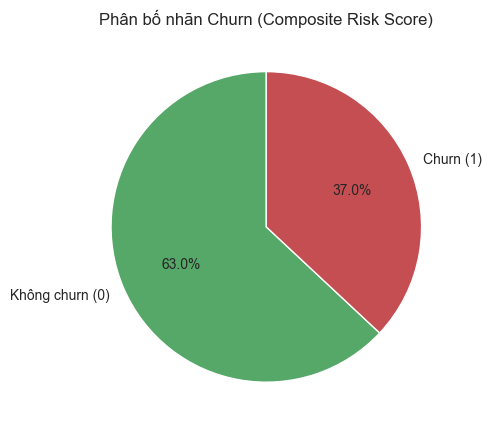

In [21]:
plt.figure(figsize=(5, 5))
plt.pie([churn_0, churn_1], labels=["Không churn (0)", "Churn (1)"],
        autopct="%1.1f%%", colors=["#55A868", "#C44E52"], startangle=90)
plt.title("Phân bố nhãn Churn (Composite Risk Score)")
plt.tight_layout()
plt.show()


Cân bằng dữ liệu bằng class weight, chia train/test

In [22]:
w_1 = data_count / (2 * churn_1) if churn_1 > 0 else 1.0
w_0 = data_count / (2 * churn_0) if churn_0 > 0 else 1.0
ml_df = ml_df.withColumn("weight", F.when(F.col("label") == 1.0, w_1).otherwise(w_0))
print(f"Class weight -> churn=1: {w_1:.3f}, churn=0: {w_0:.3f}")

train_df, test_df = ml_df.randomSplit([0.8, 0.2], seed=42)
print(f"Train: {train_df.count():,} dòng | Test: {test_df.count():,} dòng")


Class weight -> churn=1: 1.352, churn=0: 0.793
Train: 74,775 dòng | Test: 18,583 dòng


Huấn luyện GBTClassifier

In [23]:
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features", handleInvalid="skip")
gbt = GBTClassifier(featuresCol="features", labelCol="label", weightCol="weight", maxIter=50, maxDepth=5, seed=42)
gbt_pipeline = Pipeline(stages=[assembler, gbt])

print("Đang huấn luyện GBTClassifier...")
best_model = gbt_pipeline.fit(train_df)
best_preds = best_model.transform(test_df)
best_name = "GradientBoosting"
print("Huấn luyện xong.")


Đang huấn luyện GBTClassifier...
Huấn luyện xong.


Đánh giá mô hình

In [24]:
auc_eval = BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderROC")
acc_eval = MulticlassClassificationEvaluator(labelCol="label", metricName="accuracy")
f1_eval = MulticlassClassificationEvaluator(labelCol="label", metricName="f1")
prec_eval = MulticlassClassificationEvaluator(labelCol="label", metricName="weightedPrecision")
rec_eval = MulticlassClassificationEvaluator(labelCol="label", metricName="weightedRecall")

gbt_metrics = {
    "auc_roc": round(auc_eval.evaluate(best_preds), 4),
    "accuracy": round(acc_eval.evaluate(best_preds), 4),
    "f1_score": round(f1_eval.evaluate(best_preds), 4),
    "precision": round(prec_eval.evaluate(best_preds), 4),
    "recall": round(rec_eval.evaluate(best_preds), 4),
}
pd.DataFrame([gbt_metrics])


,auc_roc,accuracy,f1_score,precision,recall
0,0.9995,0.9858,0.9859,0.986,0.9853


Confusion Matrix

TP=6796  TN=11514  FP=214  FN=59


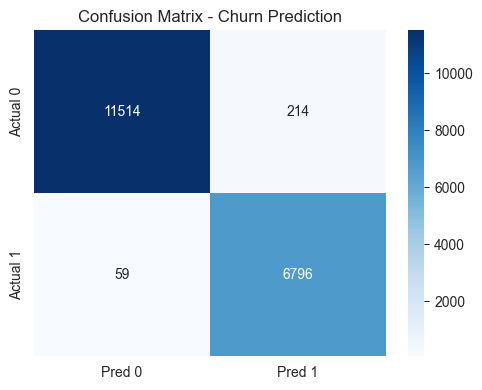

In [25]:
tp = best_preds.filter((F.col("label") == 1.0) & (F.col("prediction") == 1.0)).count()
tn = best_preds.filter((F.col("label") == 0.0) & (F.col("prediction") == 0.0)).count()
fp = best_preds.filter((F.col("label") == 0.0) & (F.col("prediction") == 1.0)).count()
fn = best_preds.filter((F.col("label") == 1.0) & (F.col("prediction") == 0.0)).count()
print(f"TP={tp}  TN={tn}  FP={fp}  FN={fn}")

cm = pd.DataFrame([[tn, fp], [fn, tp]], index=["Actual 0", "Actual 1"], columns=["Pred 0", "Pred 1"])
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Churn Prediction")
plt.tight_layout()
plt.show()


Feature Importance

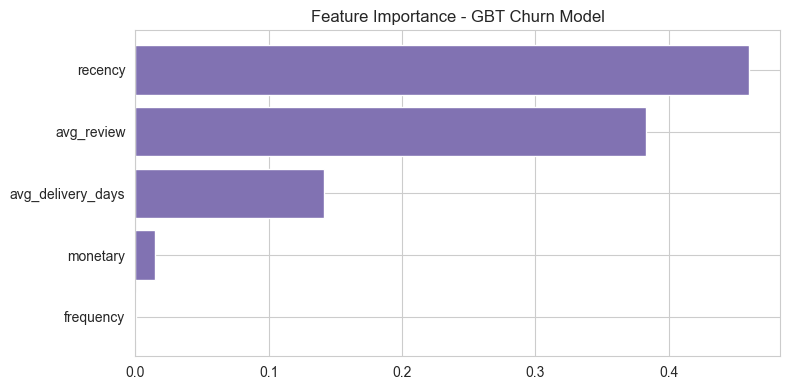

,feature,importance
0,recency,0.4603
1,avg_review,0.3829
2,avg_delivery_days,0.1414
3,monetary,0.0148
4,frequency,0.0007


In [26]:
gbt_classifier = best_model.stages[-1]
importances = gbt_classifier.featureImportances.toArray().tolist()
fi_dict = {name: round(importances[i], 4) if i < len(importances) else 0.0 for i, name in enumerate(feature_cols)}
fi_sorted = dict(sorted(fi_dict.items(), key=lambda x: x[1], reverse=True))

fi_df = pd.DataFrame(list(fi_sorted.items()), columns=["feature", "importance"])
plt.figure(figsize=(8, 4))
plt.barh(fi_df["feature"], fi_df["importance"], color="#8172B2")
plt.gca().invert_yaxis()
plt.title("Feature Importance - GBT Churn Model")
plt.tight_layout()
plt.show()
fi_df


Lưu model và kết quả dự đoán lên HDFS

In [27]:
model_path = f"{HDFS_MODELS}/churn_classifier"
best_model.write().overwrite().save(model_path)
print(f"Đã lưu model tại: {model_path}")

churn_output = (
    best_preds
    .withColumn("prob_array", vector_to_array("probability"))
    .withColumn("churn_probability", F.round(F.element_at("prob_array", 2), 4))
    .select("customer_unique_id", "label", "prediction", "churn_probability")
)
output_path = f"{HDFS_GOLD}/churn_predictions"
churn_output.coalesce(2).write.mode("overwrite").parquet(output_path)
print(f"Đã lưu churn predictions tại: {output_path}")

churn_results = {
    "model_name": "Churn_Prediction",
    "best_model": best_name,
    "models": {"GradientBoosting": gbt_metrics},
    "confusion_matrix": {
        "true_positive": int(tp), "true_negative": int(tn),
        "false_positive": int(fp), "false_negative": int(fn)
    },
    "feature_importance": fi_sorted,
    "features_used": feature_cols
}
churn_results


Đã lưu model tại: hdfs://localhost:9000/user/bigdata/olist/models/churn_classifier
Đã lưu churn predictions tại: hdfs://localhost:9000/user/bigdata/olist/gold/churn_predictions


{'model_name': 'Churn_Prediction',
 'best_model': 'GradientBoosting',
 'models': {'GradientBoosting': {'auc_roc': 0.9995,
   'accuracy': 0.9858,
   'f1_score': 0.9859,
   'precision': 0.986,
   'recall': 0.9853}},
 'confusion_matrix': {'true_positive': 6796,
  'true_negative': 11514,
  'false_positive': 214,
  'false_negative': 59},
 'feature_importance': {'recency': 0.4603,
  'avg_review': 0.3829,
  'avg_delivery_days': 0.1414,
  'monetary': 0.0148,
  'frequency': 0.0007},
 'features_used': ['recency',
  'frequency',
  'monetary',
  'avg_review',
  'avg_delivery_days']}

## 4. Lưu tổng hợp kết quả ML ra JSON

In [28]:
merged_df.unpersist()
rfm_df.unpersist()

start_time = datetime.now()
all_results = {
    "kmeans_segmentation": kmeans_results,
    "churn_prediction": churn_results,
    "timestamp": start_time.isoformat(),
}

os.makedirs("tmp_models", exist_ok=True)
json_path = os.path.join("tmp_models", "ml_results.json")
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(all_results, f, indent=2, ensure_ascii=False)
print(f"Đã lưu kết quả ML tại: {json_path}")

print("=" * 60)
print("HOÀN THÀNH HUẤN LUYỆN MÔ HÌNH (Spark MLlib)")
print(f"  Mô hình 1: K-Means Segmentation - Silhouette: {kmeans_results['silhouette_score']}")
print(f"  Mô hình 2: Churn ({churn_results['best_model']}) - AUC: {gbt_metrics['auc_roc']}, F1: {gbt_metrics['f1_score']}")
print("=" * 60)


Đã lưu kết quả ML tại: tmp_models\ml_results.json
HOÀN THÀNH HUẤN LUYỆN MÔ HÌNH (Spark MLlib)
  Mô hình 1: K-Means Segmentation - Silhouette: 0.3054
  Mô hình 2: Churn (GradientBoosting) - AUC: 0.9995, F1: 0.9859


In [29]:
spark.stop()
print("SparkSession đã dừng.")


SparkSession đã dừng.


## 5. Train mô hình Scikit-Learn nhẹ cho Flask API (đọc từ MongoDB)

Composite Churn Risk: 30% recency, 20% avg_delivery_days, 20% avg_review_score, 15% frequency, 15% monetary

In [30]:
import pymongo
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix
import joblib

client = pymongo.MongoClient("mongodb://localhost:27017/")
db = client["olist_dw"]
df = pd.DataFrame(list(db["customers"].find({}, {
    "_id": 0, "recency": 1, "frequency": 1, "monetary": 1,
    "avg_review_score": 1, "avg_delivery_days": 1
})))

print(f"Đã đọc {len(df):,} dòng từ MongoDB")
df.fillna(0, inplace=True)
df.head()


2026-07-14 16:41:58,027 [INFO] {"message": "Waiting for suitable server to become available", "selector": "Primary()", "operation": "find", "topologyDescription": "<TopologyDescription id: 6a5604652a0ddf83f693ec42, topology_type: Unknown, servers: [<ServerDescription ('localhost', 27017) server_type: Unknown, rtt: None>]>", "clientId": {"$oid": "6a5604652a0ddf83f693ec42"}, "remainingTimeMS": 29}


Đã đọc 93,358 dòng từ MongoDB


,recency,frequency,monetary,avg_review_score,avg_delivery_days
0,334,1,13664.08,1.0,18.0
1,515,2,7571.63,5.0,16.0
2,45,1,7274.88,1.0,11.0
3,563,1,6929.31,5.0,19.0
4,35,1,6922.21,0.0,21.0


Chuẩn hóa và tính Composite Risk Score

Composite label => Churn=1: 24,296, Churn=0: 69,062


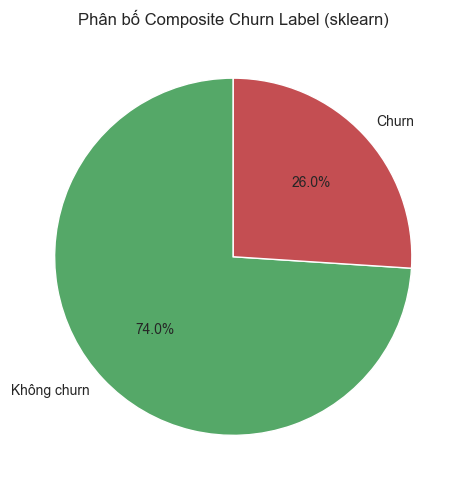

In [31]:
def norm(col):
    mn, mx = col.min(), col.max()
    return (col - mn) / (mx - mn) if mx > mn else col * 0

rec_n  = norm(df["recency"])
freq_n = norm(df["frequency"])
mon_n  = norm(df["monetary"])
rev_n  = norm(df["avg_review_score"])
del_n  = norm(df["avg_delivery_days"])

risk = (
    0.30 * rec_n +
    0.15 * (1 - freq_n) +
    0.15 * (1 - mon_n) +
    0.20 * (1 - rev_n) +
    0.20 * del_n
)

y = (risk > 0.50).astype(int)
churn_1 = int(y.sum())
churn_0 = int(len(y) - churn_1)
print(f"Composite label => Churn=1: {churn_1:,}, Churn=0: {churn_0:,}")

plt.figure(figsize=(5, 5))
plt.pie([churn_0, churn_1], labels=["Không churn", "Churn"], autopct="%1.1f%%",
        colors=["#55A868", "#C44E52"], startangle=90)
plt.title("Phân bố Composite Churn Label (sklearn)")
plt.tight_layout()
plt.show()


Chia train/test, chuẩn hóa feature

In [32]:
feature_names = ["recency", "frequency", "monetary", "avg_review_score", "avg_delivery_days"]
X = df[feature_names]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")


Train: 74,686 | Test: 18,672


Huấn luyện GradientBoostingClassifier

In [33]:
model = GradientBoostingClassifier(
    n_estimators=150, max_depth=5, learning_rate=0.1, subsample=0.8, random_state=42
)
model.fit(X_train, y_train)
print("Huấn luyện xong.")


Huấn luyện xong.


Đánh giá mô hình

Accuracy: 0.9972, F1: 0.9946, AUC: 0.9999


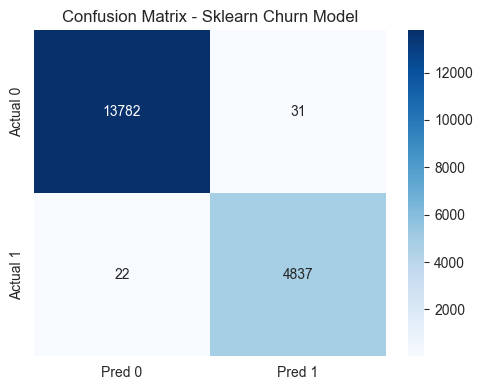

In [34]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
print(f"Accuracy: {acc:.4f}, F1: {f1:.4f}, AUC: {auc:.4f}")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(pd.DataFrame(cm, index=["Actual 0", "Actual 1"], columns=["Pred 0", "Pred 1"]),
            annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Sklearn Churn Model")
plt.tight_layout()
plt.show()


Feature importance

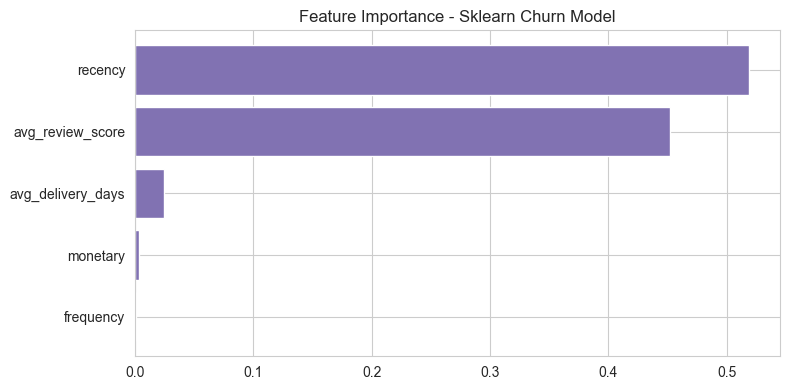

,feature,importance
0,recency,0.5192
3,avg_review_score,0.4524
4,avg_delivery_days,0.0241
2,monetary,0.0034
1,frequency,0.0009


In [35]:
fi = dict(zip(feature_names, [round(v, 4) for v in model.feature_importances_]))
fi_df_sk = pd.DataFrame(list(fi.items()), columns=["feature", "importance"]).sort_values("importance", ascending=False)

plt.figure(figsize=(8, 4))
plt.barh(fi_df_sk["feature"], fi_df_sk["importance"], color="#8172B2")
plt.gca().invert_yaxis()
plt.title("Feature Importance - Sklearn Churn Model")
plt.tight_layout()
plt.show()
fi_df_sk


Lưu model

In [36]:
os.makedirs("tmp_models", exist_ok=True)
joblib.dump({
    "scaler": scaler,
    "model": model,
    "feature_names": feature_names,
}, "tmp_models/churn_prediction.joblib")
print("Đã lưu model tại tmp_models/churn_prediction.joblib")


Đã lưu model tại tmp_models/churn_prediction.joblib
